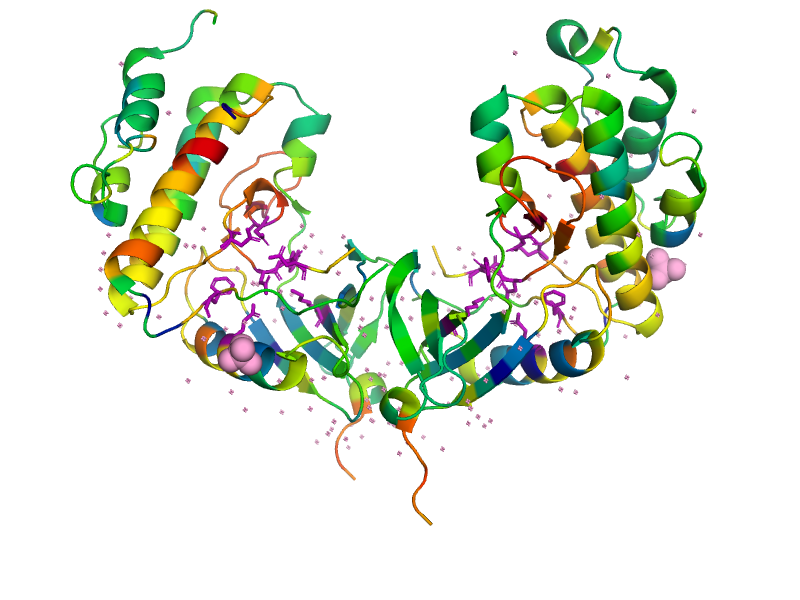

In [7]:
import pymol2

session_path = "/home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/explanations/MKNK1_HUMAN/MKNK1_HUMAN_attention_layer2_scene.pse"
with pymol2.PyMOL() as pymol:
    cmd = pymol.cmd

    pymol.start()

    cmd.load(session_path)

    # cmd.hide("everything", "all")

    # Show small ligands (hetatms, non-polymer) and color them pink
    cmd.show("sticks", "hetatm and not polymer")
    cmd.color("pink", "hetatm and not polymer")

    # Define active-site selection
    cmd.select("active_site", "resi 192+78+191+193+170+175+230+94")

    # Show active-site residues as sticks and color them purple
    cmd.show("sticks", "active_site")
    cmd.color("purple", "active_site")

    # Zoom to the active site plus ligands
    cmd.zoom("active_site or (hetatm and not polymer)")
    cmd.ray(800, 600)  # Render current view at 800x600 pixels [web:47][web:48]
    
    # save as high res PNG
    png_path = session_path.replace(".pse", ".png")
    cmd.png(png_path, 1600, 1200, dpi=300,ray=1)
    img = cmd.ipython_image(width=800, height=600, ray=1)
img
    

Missing scene: /home/atoffano/PFP_layer/results/D1/20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR/explanations/MKNK1_MOUSE/MKNK1_MOUSE_attention_layer2_scene.pse


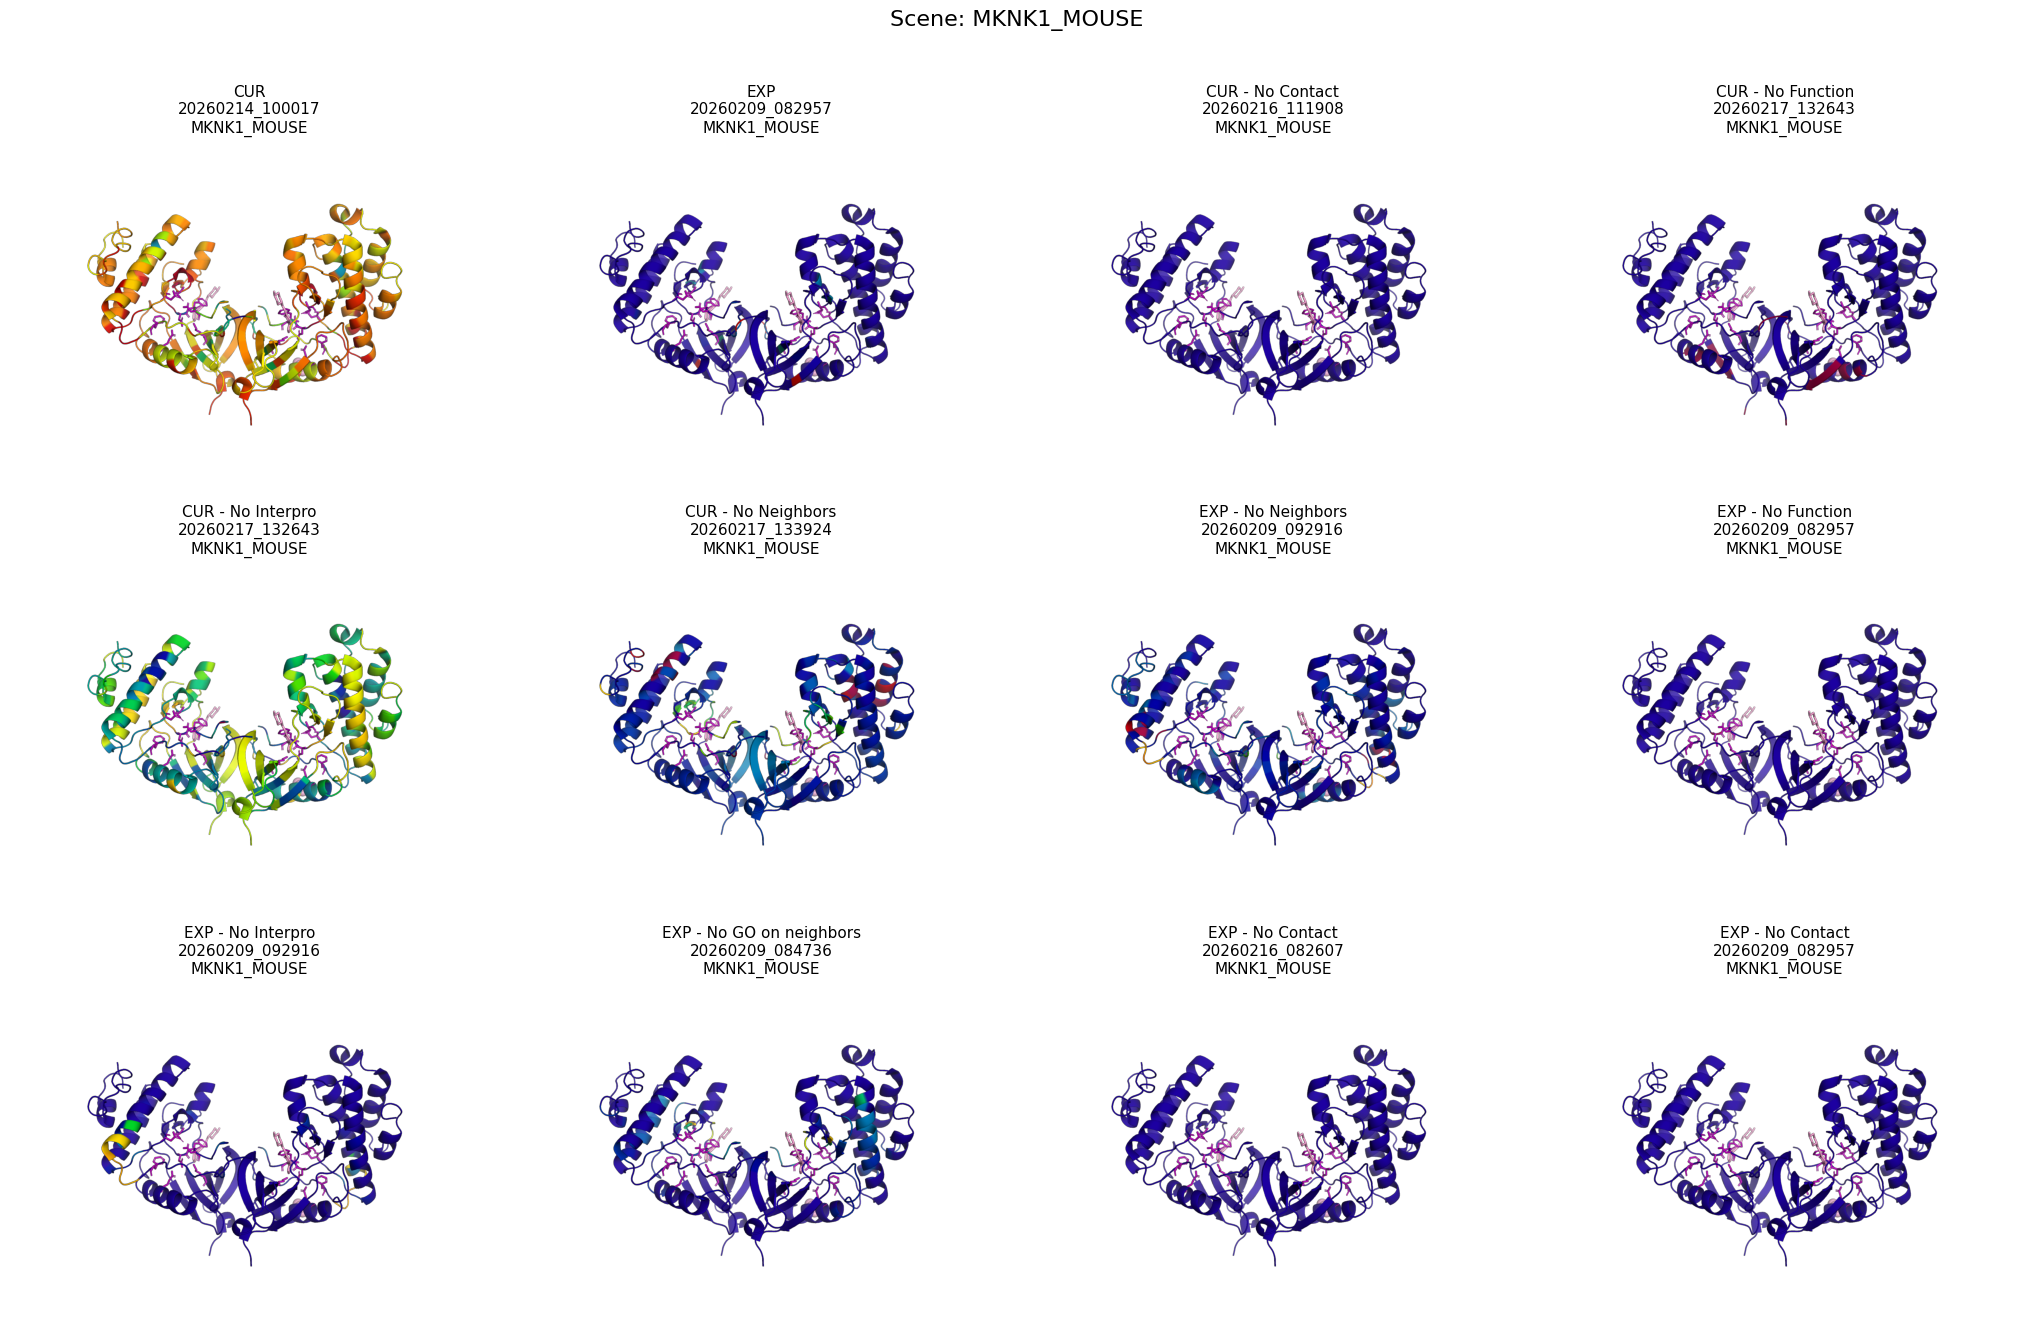

Missing scene: /home/atoffano/PFP_layer/results/D1/20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR/explanations/NAA30_SCHPO/NAA30_SCHPO_attention_layer2_scene.pse


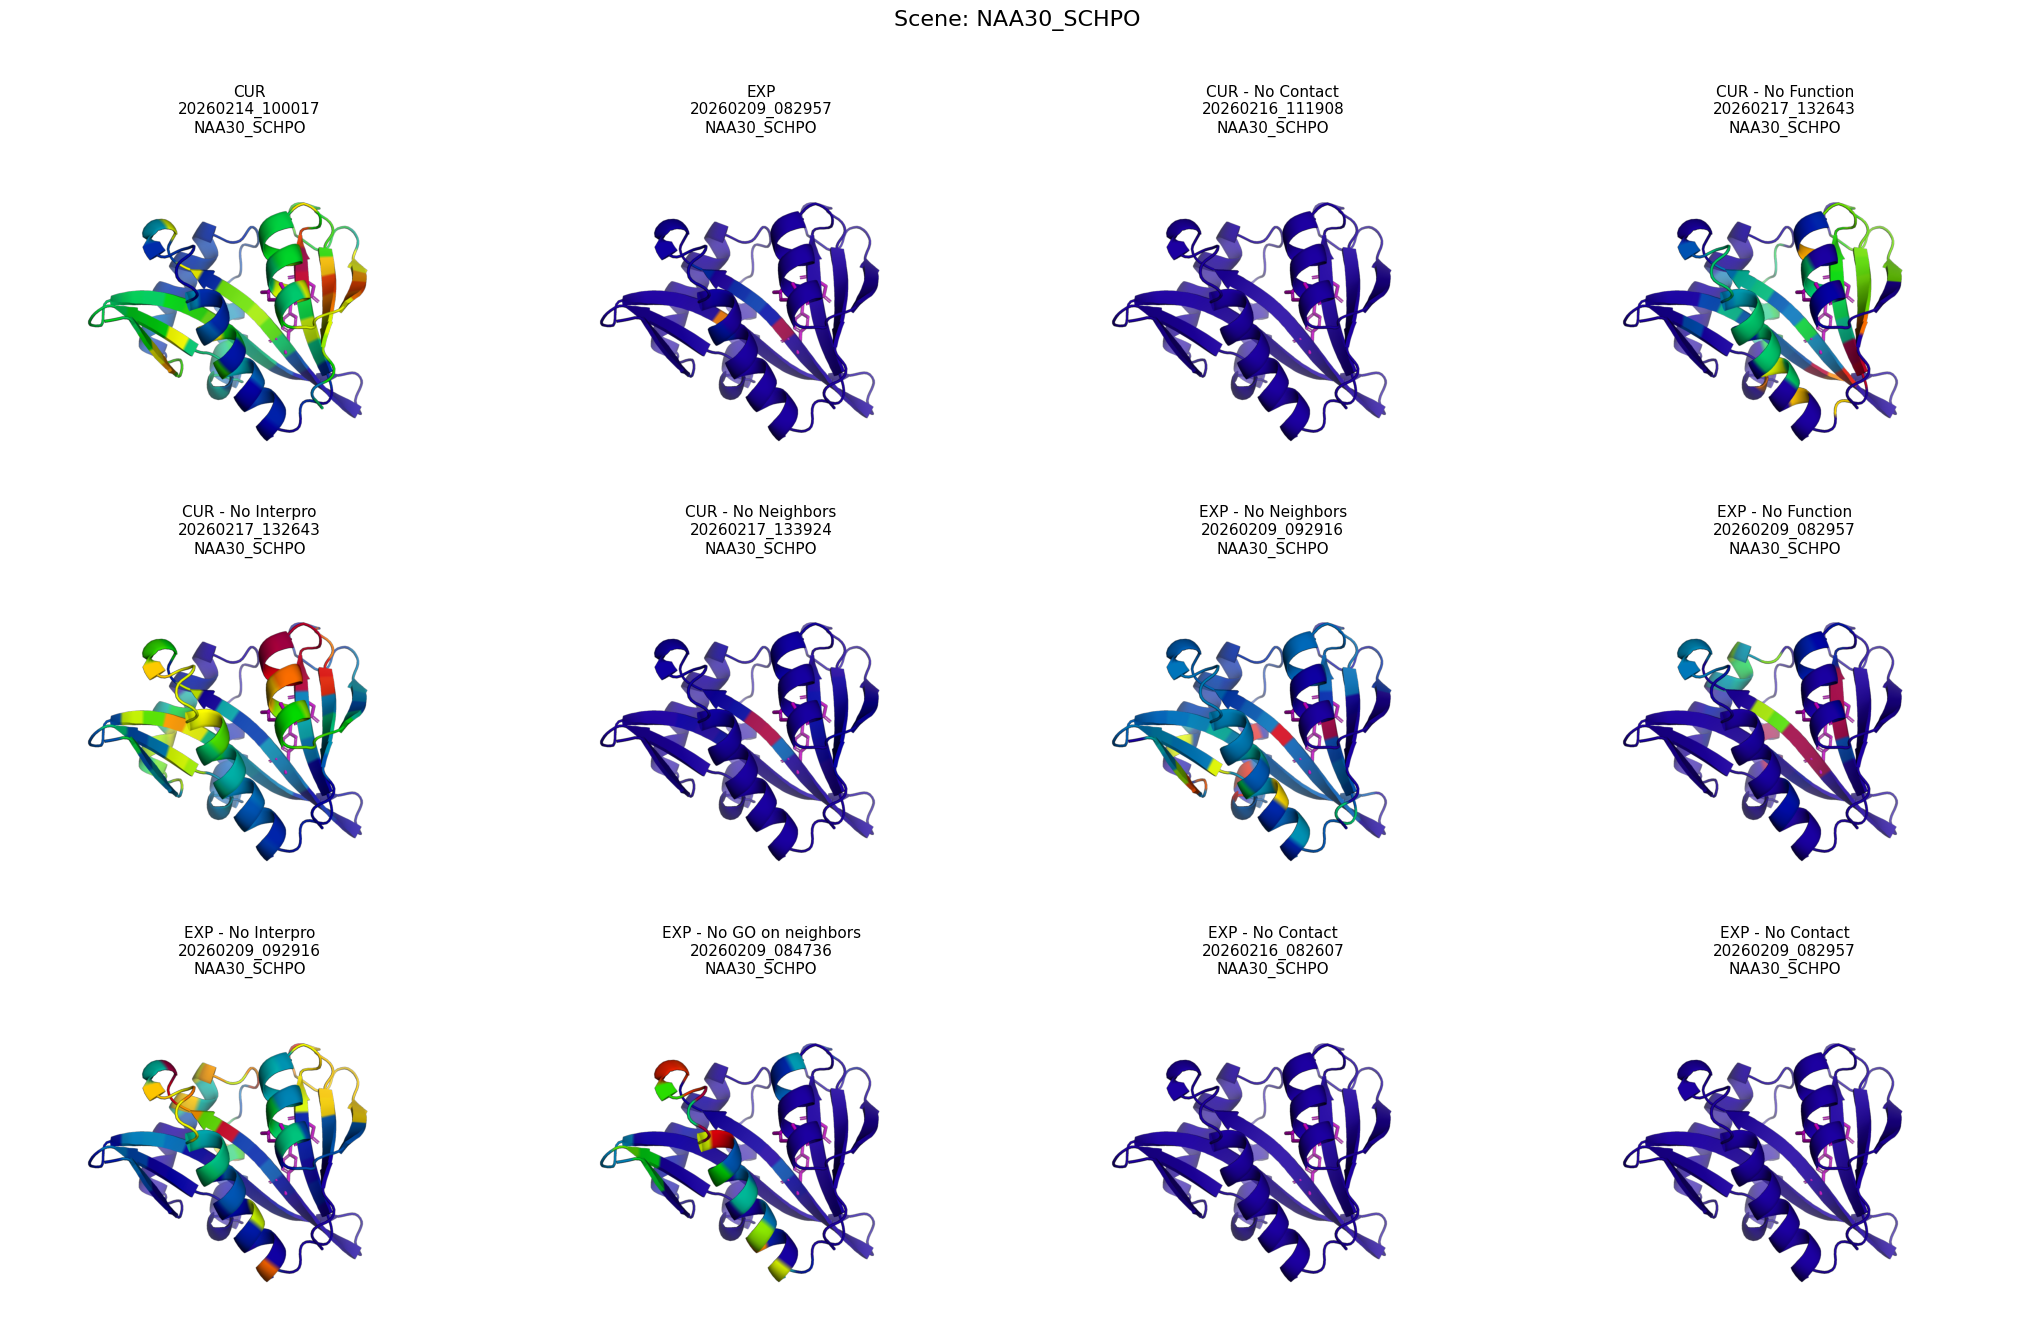

Missing scene: /home/atoffano/PFP_layer/results/D1/20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR/explanations/ST2A8_MOUSE/ST2A8_MOUSE_attention_layer2_scene.pse


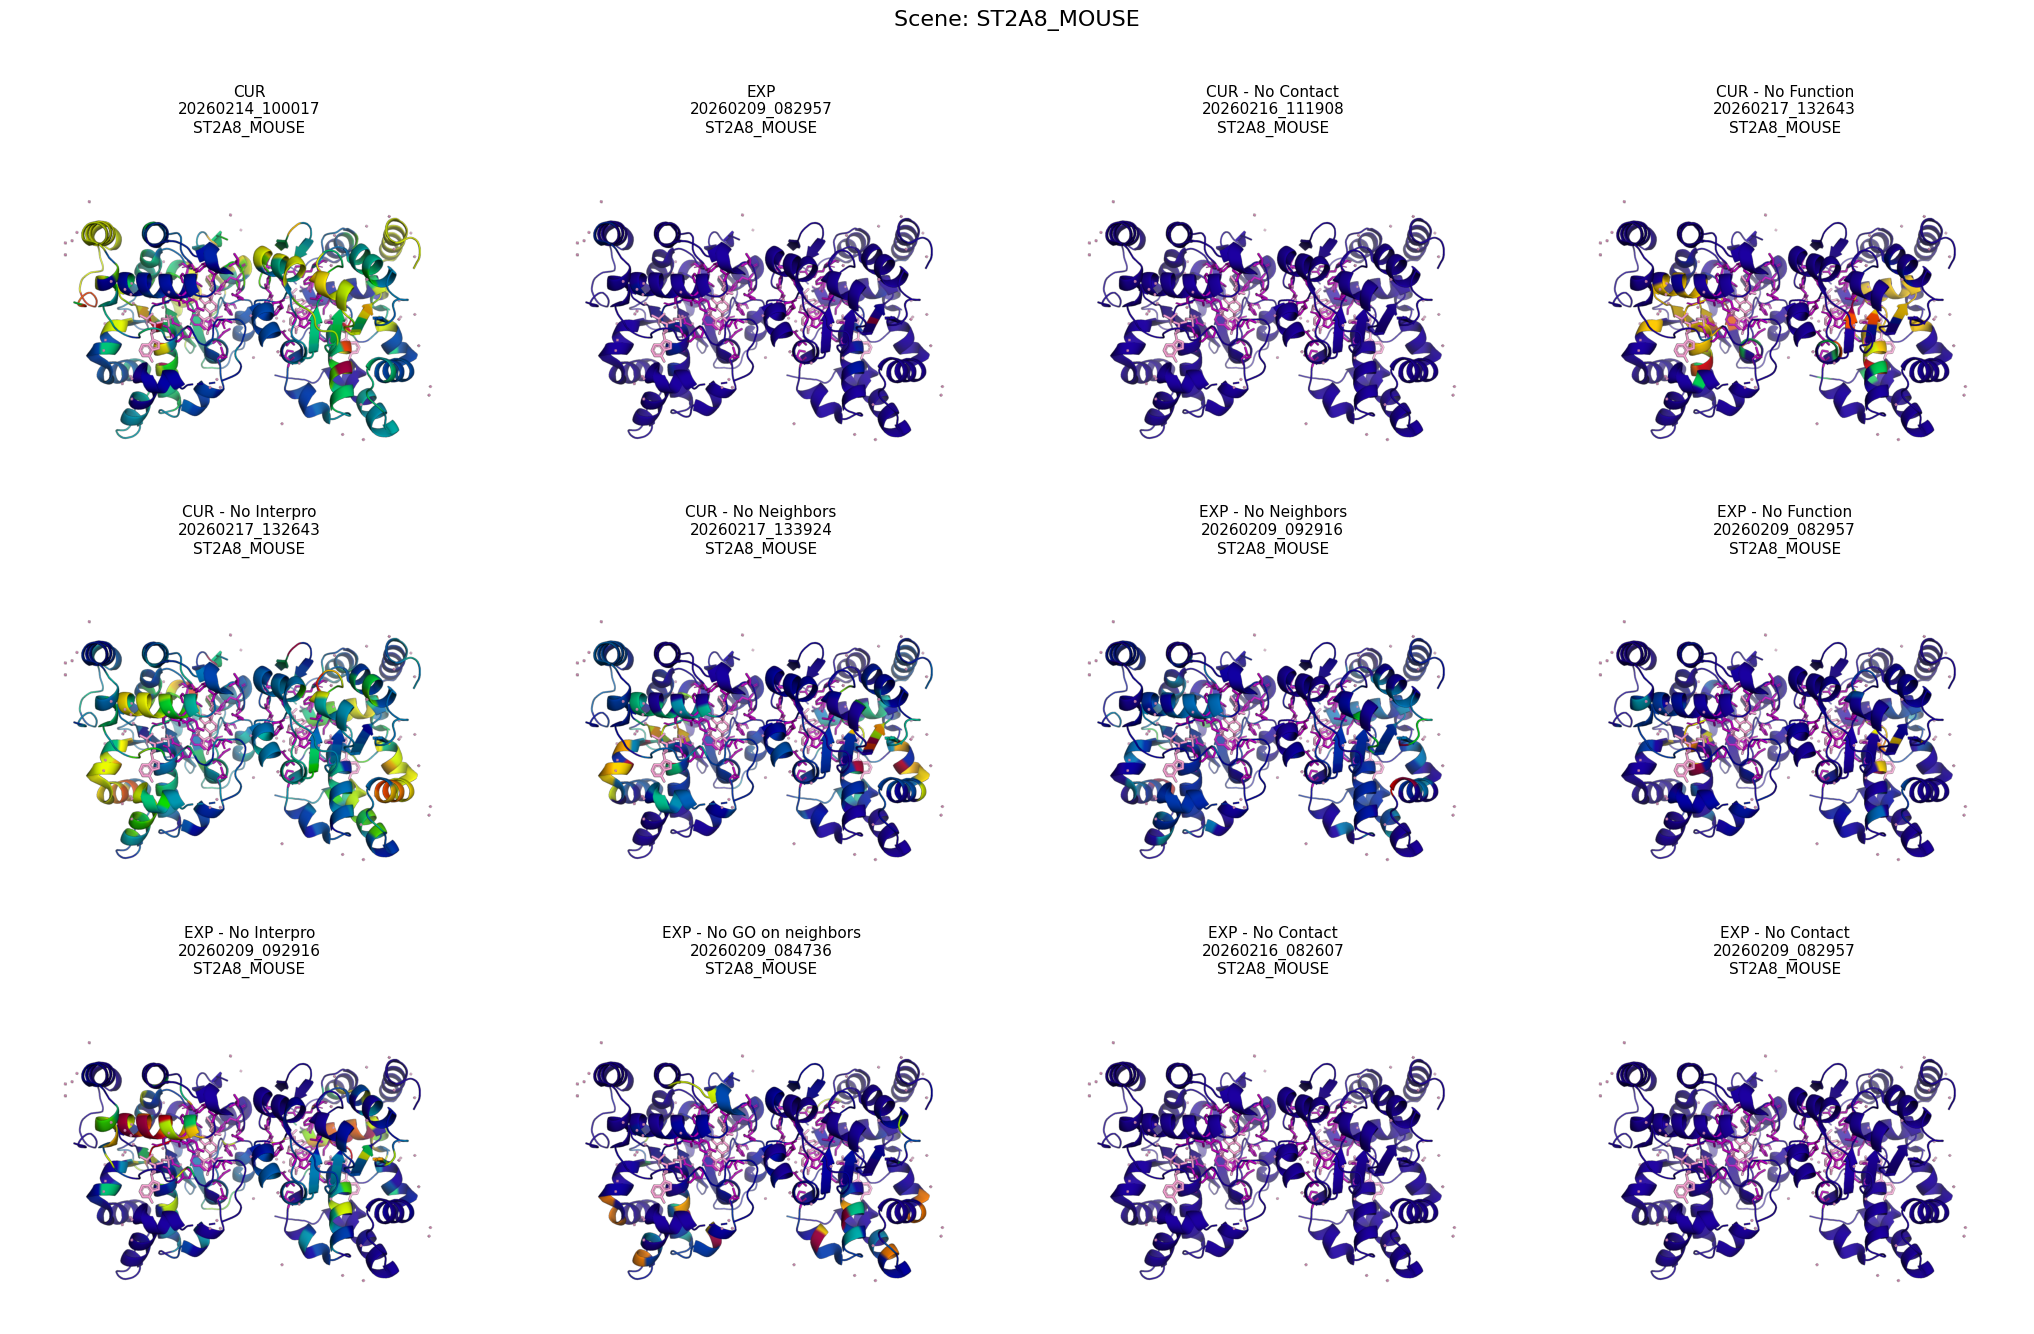

In [8]:
SELECTED_MODEL_DIRS = {
    "D1": [
        "20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR", #MFO
        "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", # MFO
        "20260216_111908_D1_2024_01_GNN_DEL_CONTACT_CUR", # ALL 3
        "20260217_132643_D1_2024_01_GNN_DEL_NOFUNC_CUR", #MFO
        "20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR", # ALL 3
        "20260217_132643_D1_2024_01_GNN_DEL_NOIPR_CUR", # ALL 3
        "20260217_133924_D1_2024_01_GNN_DEL_NOSYS_CUR", # MFO
        "20260209_092916_D1_2024_01_GNN_DEL_NOSYS",     # MFO
        "20260209_082957_D1_2024_01_GNN_DEL_NOFUNC",    # MFO
        "20260209_092916_D1_2024_01_GNN_DEL_NOIPR",     # MFO
        "20260209_084736_D1_2024_01_GNN_DEL_NOGO",      # MFO
        "20260216_082607_D1_2024_01_GNN_DEL_CONTACT",   # MFO, CCO
        "20260209_082957_D1_2024_01_GNN_DEL_CONTACT",   # MFO
    ],
}

LEGEND_NAME_MAP = {
    "20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR": "CUR", #MFO
    "20260216_111908_D1_2024_01_GNN_DEL_CONTACT_CUR": "CUR - No Contact", # ALL 3
    "20260217_132643_D1_2024_01_GNN_DEL_NOFUNC_CUR": "CUR - No Function", #MFO
    "20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR": "CUR - No GO on neighbors", # ALL 3
    "20260217_132643_D1_2024_01_GNN_DEL_NOIPR_CUR": "CUR - No Interpro", # ALL 3
    "20260217_133924_D1_2024_01_GNN_DEL_NOSYS_CUR": "CUR - No Neighbors", # MFO

    "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB": "EXP", # MFO
    "20260209_092916_D1_2024_01_GNN_DEL_NOSYS": "EXP - No Neighbors",
    "20260209_082957_D1_2024_01_GNN_DEL_NOFUNC": "EXP - No Function",
    "20260209_092916_D1_2024_01_GNN_DEL_NOIPR": "EXP - No Interpro",
    "20260209_084736_D1_2024_01_GNN_DEL_NOGO": "EXP - No GO on neighbors",
    "20260216_082607_D1_2024_01_GNN_DEL_CONTACT": "EXP - No Contact",
    "20260209_082957_D1_2024_01_GNN_DEL_CONTACT": "EXP - No Contact",
}


scene_targets = [
    "MKNK1_MOUSE",
    "NAA30_SCHPO",
    "ST2A8_MOUSE",
]

ACTIVE_SITE_BY_TARGET = {
    "ST2A8_MOUSE": "15+138+159+133+134+44+160+18+17+99+237+80+47+48+77+72+70",
    "NAA30_SCHPO": "71+109+121",
    "MKNK1_MOUSE": "192+78+191+193+170+175+230+94",
}

def _render_scene_png(scene_path, out_png, target=None, width=1400, height=1000, dpi=250):
    if not os.path.exists(scene_path):
        return False

    if target is None:
        base = os.path.basename(scene_path)
        suffix = "_attention_layer2_scene.pse"
        if base.endswith(suffix):
            target = base[:-len(suffix)]

    active_site_resi = ACTIVE_SITE_BY_TARGET.get(target)

    with pymol2.PyMOL() as pymol:
        pymol.start()
        c = pymol.cmd
        c.reinitialize()
        c.load(scene_path)

        # Show small ligands (hetatms, non-polymer) and color them pink
        c.show("sticks", "hetatm and not polymer")
        c.color("pink", "hetatm and not polymer")

        # Define active-site selection for all targets
        if active_site_resi:
            c.select("active_site", f"resi {active_site_resi}")
        else:
            c.select("active_site", "none")

        # Show active-site residues as sticks and color them purple
        c.show("sticks", "active_site")
        # c.color("purple", "active_site")
        c.set("stick_color", "purple", "active_site")

        # Zoom to the active site plus ligands
        # c.zoom("active_site or (hetatm and not polymer)")

        c.png(out_png, width, height, dpi=dpi, ray=1)
    return os.path.exists(out_png)

def _plot_scene_grid(scene_name, rendered_items, max_cols=4):
    n = len(rendered_items)
    if n == 0:
        print(f"No images found for scene: {scene_name}")
        return

    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[n:]:
        ax.axis("off")

    for i, item in enumerate(rendered_items):
        ax = axes[i]
        img_arr = plt.imread(item["png"])
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(item["label"], fontsize=11)

    fig.suptitle(f"Scene: {scene_name}", fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()

dataset = "D1"
model_dirs = SELECTED_MODEL_DIRS.get(dataset, [])

for target in scene_targets:
    rendered = []
    for model_dir in model_dirs:
        scene_path = os.path.join(
            RESULTS_ROOT,
            dataset,
            model_dir,
            "explanations",
            target,
            f"{target}_attention_layer2_scene.pse",
        )
        out_png = os.path.join(PLOTS_DIR, f"{model_dir}_{target}_scene.png")
        ok = _render_scene_png(scene_path, out_png, target=target)

        legend = LEGEND_NAME_MAP.get(model_dir, model_dir.split("GNN_")[-1])
        run_id = model_dir.split("_D1_")[0]
        label = f"{legend}\n{run_id}\n{target}"

        if ok:
            rendered.append({"png": out_png, "label": label})
        else:
            print(f"Missing scene: {scene_path}")

    _plot_scene_grid(target, rendered, max_cols=4)